# 🪐 Exoplanet Detection with Kepler Light Curves
**NASA Kepler data + AstroNet-style 1D CNN**

This notebook:
1. Downloads labeled Kepler KOI data from NASA
2. Fetches real light curves via `lightkurve`
3. Visualizes confirmed planets vs false positives
4. Trains a 1D CNN to classify transit signals
5. Evaluates with confusion matrix, ROC and precision-recall curves
6. Lets you predict on any Kepler star

> **Recommended:** `Runtime > Change runtime type > T4 GPU`

## 📦 Step 1: Install Dependencies

In [1]:
# Fix fsspec version conflict between s3fs/gcsfs/datasets before installing lightkurve
import subprocess, sys

print('📦 Installing dependencies (fixing fsspec conflict)...')

# Step 1: pin fsspec to a version compatible with both gcsfs and datasets
# This resolves potential conflicts between different libraries requiring specific fsspec versions.
subprocess.run([sys.executable, '-m', 'pip', 'install', 'fsspec==2025.3.0', '-q', '--no-deps'], check=False)

# Step 2: install lightkurve and scikit-learn quietly
# lightkurve is used for fetching and analyzing light curve data.
# scikit-learn is used for machine learning utilities like train-test split and evaluation metrics.
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightkurve', 'scikit-learn', '-q'], check=False)

# Suppress all pip warnings in subsequent cells
# This keeps the output cleaner by hiding non-critical warnings from pip.
import warnings
warnings.filterwarnings('ignore')

print('✅ Dependencies installed successfully')

📦 Installing dependencies (fixing fsspec conflict)...
✅ Dependencies installed successfully


## 📥 Step 2: Download NASA KOI Catalog (Labels)

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print('Downloading NASA KOI catalog...')
# Define the URL for the NASA Exoplanet Archive KOI (Kepler Object of Interest) cumulative table.
# This URL specifies the desired columns (kepid, kepoi_name, koi_disposition, etc.) and CSV format.
url = (
    'https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI'
    '?table=cumulative'
    '&select=kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad'
    '&format=csv'
)
# Read the CSV data directly into a pandas DataFrame.
df_koi = pd.read_csv(url, comment='#')
print(f'✅ Downloaded {len(df_koi)} KOI entries')
# Display the first few rows of the downloaded DataFrame to inspect its structure and content.
df_koi.head()

✅ Downloaded 9564 KOI entries


,kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad
0,10797460,K00752.01,CONFIRMED,9.488036,170.538750,2.95750,615.8,2.26
1,10797460,K00752.02,CONFIRMED,54.418383,162.513840,4.50700,874.8,2.83
2,10811496,K00753.01,CANDIDATE,19.899140,175.850252,1.78220,10829.0,14.60
3,10848459,K00754.01,FALSE POSITIVE,1.736952,170.307565,2.40641,8079.2,33.46
4,10854555,K00755.01,CONFIRMED,2.525592,171.595550,1.65450,603.3,2.75


In [3]:
# Filter the DataFrame to separate confirmed planets and false positives.
df_confirmed = df_koi[df_koi['koi_disposition'] == 'CONFIRMED'].copy()
df_fp        = df_koi[df_koi['koi_disposition'] == 'FALSE POSITIVE'].copy()

print(f'✅ Confirmed planets: {len(df_confirmed)}')
print(f'❌ False positives:   {len(df_fp)}')

# Determine the sample size for balancing the dataset.
# We take the minimum count to ensure both classes have the same number of samples.
n_sample = min(200, len(df_confirmed), len(df_fp))
# Randomly sample 'n_sample' confirmed planets and false positives.
df_pos = df_confirmed.sample(n=n_sample, random_state=42)
df_neg = df_fp.sample(n=n_sample, random_state=42)
# Assign labels: 1 for confirmed planets, 0 for false positives.
df_pos['label'] = 1
df_neg['label'] = 0

# Concatenate the sampled DataFrames to create the final balanced dataset.
df_dataset = pd.concat([df_pos, df_neg]).reset_index(drop=True)
print(f'\n📊 Balanced dataset: {len(df_dataset)} total ({n_sample} each class)')

✅ Confirmed planets: 2746
❌ False positives:   4839

📊 Balanced dataset: 400 total (200 each class)


## 🔭 Step 3: Light Curve Helper Function

In [4]:
import lightkurve as lk
import matplotlib.pyplot as plt
import matplotlib
# Set the default DPI for matplotlib figures for better resolution.
matplotlib.rcParams['figure.dpi'] = 120

# Define the number of bins for folding light curves.
BINS = 201

def download_and_fold(kepler_id, period, t0, bins=BINS):
    """Downloads a Kepler light curve, flattens it, folds it by period,
       bins it, and normalizes the flux values.

    Args:
        kepler_id (int): The Kepler ID of the star.
        period (float): The orbital period of the exoplanet candidate.
        t0 (float): The time of transit center.
        bins (int): The number of bins to use for the folded light curve.

    Returns:
        np.ndarray: Normalized flux array if successful, None otherwise.
    """
    try:
        # Search for long cadence Kepler light curves for the given Kepler ID.
        search = lk.search_lightcurve(f'KIC {int(kepler_id)}', mission='Kepler', cadence='long')
        if len(search) == 0:
            return None
        # Download the first light curve found.
        lc = search[0].download()
        if lc is None:
            return None
        # Flatten the light curve to remove long-term variability.
        lc_flat = lc.flatten(window_length=101)
        # Fold the light curve using the provided period and epoch (t0).
        lc_fold = lc_flat.fold(period=period, epoch_time=t0)
        # Bin the folded light curve to a fixed number of bins.
        lc_bin  = lc_fold.bin(bins=bins)
        # Extract flux values.
        flux = lc_bin.flux.value
        # Normalize the flux: subtract median and divide by standard deviation.
        # Add a small epsilon (1e-8) to avoid division by zero if std is 0.
        flux = (flux - np.nanmedian(flux)) / (np.nanstd(flux) + 1e-8)
        # Pad or truncate the flux array to ensure it has exactly 'bins' length.
        if len(flux) < bins:
            flux = np.pad(flux, (0, bins - len(flux)), constant_values=0)
        else:
            flux = flux[:bins]
        return flux
    except Exception:
        # Return None if any error occurs during the process.
        return None

print('✅ Function ready')

✅ Function ready


## 🌟 Step 4: Visualize Example Light Curves

In [ ]:
# ✅ verified in MAST
examples = [
    (11442793, 14.44912, 2.2,  'CONFIRMED',      'Kepler-90g'),
    (3544595,   4.88780, 0.5,  'CONFIRMED',      'Kepler-42b'),
    (9941662,   4.9278,  1.2,  'FALSE POSITIVE', 'KOI-189 (FP)'),
    (5358624,   3.521,   0.3,  'FALSE POSITIVE', 'KOI-203 (FP)'),
]

# Create a figure and a grid of subplots for visualizing light curves.
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle('Kepler Phase-Folded Light Curves', fontsize=14, fontweight='bold')
# Define the x-axis values for the phase-folded light curves, ranging from -0.5 to 0.5.
x_axis = np.linspace(-0.5, 0.5, BINS)

# Iterate through the example exoplanet candidates.
for i, (kid, period, t0, disposition, name) in enumerate(examples):
    # Determine the subplot position based on the iteration index.
    ax = axes[i // 2][i % 2]
    # Download and fold the light curve for the current example.
    flux = download_and_fold(kid, period, t0)
    # Set the color based on the disposition (confirmed or false positive).
    color = '#2196F3' if disposition == 'CONFIRMED' else '#F44336'
    if flux is not None:
        # Plot the folded light curve.
        ax.plot(x_axis, flux, color=color, linewidth=1.2)
        # Fill the area under the curve for visual emphasis.
        ax.fill_between(x_axis, flux, alpha=0.15, color=color)
        # Add a horizontal line at y=0 for reference.
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    else:
        # If download fails, display a message.
        ax.text(0.5, 0.5, 'Download failed', ha='center', va='center',
                transform=ax.transAxes, color='gray')
    # Set the title for the subplot, including name and disposition.
    ax.set_title(f'{name}  |  {disposition}', fontsize=10,
                 color='#1565C0' if disposition == 'CONFIRMED' else '#C62828')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Normalized Flux')
    ax.set_xlim(-0.5, 0.5)

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('lightcurve_examples.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('✅ Saved lightcurve_examples.png')

## 📊 Step 5: Build Training Dataset

⏱️ Takes ~10–15 min — downloads ~400 light curves from NASA MAST.

In [18]:
from tqdm.notebook import tqdm

X_list, y_list, failed, rejected_nan = [], [], 0, 0

print(f"Downloading & filtering light curves for {len(df_dataset)} KOIs...")
print("⏱️  This may take 15–20 min depending on network speed.\n")

for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    flux = download_and_fold(row['kepid'], row['koi_period'], row['koi_time0bk'])

    # --- Filter 1: download must succeed ---
    if flux is None:
        failed += 1
        continue

    # --- Filter 2: must have enough real (non-NaN) values ---
    nan_fraction = np.isnan(flux).mean()
    if nan_fraction > 0.1:          # reject if >10% of bins are NaN
        rejected_nan += 1
        continue

    # --- Filter 3: flux must show some variation (not flat/dead signal) ---
    flux_std = np.nanstd(flux)
    if flux_std < 1e-4:
        rejected_nan += 1
        continue

    # --- Filter 4: fill any remaining isolated NaNs with 0 ---
    flux = np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)

    X_list.append(flux)
    y_list.append(row['label'])

X = np.array(X_list)
y = np.array(y_list)

print(f"\n✅ Usable light curves  : {len(X)}")
print(f"❌ Download failed      : {failed}")
print(f"🚫 Rejected (bad data)  : {rejected_nan}")
print(f"📊 Planets: {y.sum():.0f}  |  False Positives: {(y==0).sum():.0f}")

# Final NaN sanitization pass — safety net
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print("\n✅ NaN sanitization applied — dataset is clean")

⏱️  This may take 15–20 min depending on network speed.



  0%|          | 0/400 [00:00<?, ?it/s]


✅ Usable light curves  : 320
❌ Download failed      : 80
🚫 Rejected (bad data)  : 0
📊 Planets: 173  |  False Positives: 147

✅ NaN sanitization applied — dataset is clean


## 🧠 Step 6: Build & Train 1D CNN

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Reshape the input features (X) to be compatible with a 1D CNN.
# It needs to be (number_of_samples, sequence_length, features_per_step).
X_cnn = X.reshape(X.shape[0], BINS, 1)

# Split the dataset into training and testing sets.
# stratify=y ensures that both training and testing sets have a similar proportion of classes.
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y)

# Further split the training set into training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

def build_model(n=BINS):
    """Builds a 1D Convolutional Neural Network model for exoplanet detection.

    Args:
        n (int): The input sequence length (number of bins in the light curve).

    Returns:
        keras.Model: The compiled Keras model.
    """
    # Define the input layer with the shape of the light curve data.
    inp = keras.Input(shape=(n, 1))
    # First convolutional block: Conv1D -> MaxPooling1D
    x = layers.Conv1D(16,  5, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(2)(x)
    # Second convolutional block
    x = layers.Conv1D(32,  5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    # Third convolutional block
    x = layers.Conv1D(64,  5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    # Fourth convolutional block
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    # Flatten the output of the convolutional layers to feed into dense layers.
    x = layers.Flatten()(x)
    # First dense layer with ReLU activation and dropout for regularization.
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    # Second dense layer with ReLU activation and dropout.
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    # Output layer with a single neuron and sigmoid activation for binary classification.
    out = layers.Dense(1, activation='sigmoid')(x)
    # Create the Keras model.
    return keras.Model(inp, out)

# Instantiate the model.
model = build_model()
# Compile the model with Adam optimizer, binary cross-entropy loss, and various metrics.
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
# Print a summary of the model's architecture.
model.summary()

Train: 217  Val: 39  Test: 64


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 201, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 50, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 25, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 972,609 (3.71 MB)

 Trainable params: 972,609 (3.71 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Define callbacks for training.
callbacks = [
    # EarlyStopping: Stops training when a monitored metric (val_auc) stops improving.
    # patience=8 means it waits for 8 epochs with no improvement before stopping.
    # restore_best_weights=True restores the model weights from the epoch with the best monitored value.
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                  monitor='val_auc', mode='max'),
    # ReduceLROnPlateau: Reduces the learning rate when a metric (val_loss) has stopped improving.
    # patience=4 means it waits for 4 epochs with no improvement.
    # factor=0.5 means the learning rate will be reduced by a factor of 0.5.
    keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5,
                                      monitor='val_loss', verbose=1)
]

# Train the model using the training data and validate with the validation data.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=32,
    callbacks=callbacks, verbose=1
)
print('\n✅ Training complete!')

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 970ms/step - accuracy: 0.5571 - auc: 0.5766 - loss: 0.6887 - precision: 0.6078 - recall: 0.4006 - val_accuracy: 0.5897 - val_auc: 0.5251 - val_loss: 0.6873 - val_precision: 0.5862 - val_recall: 0.8095 - learning_rate: 1.0000e-04
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6181 - auc: 0.6623 - loss: 0.6687 - precision: 0.5994 - recall: 0.8483 - val_accuracy: 0.6154 - val_auc: 0.5132 - val_loss: 0.6869 - val_precision: 0.5938 - val_recall: 0.9048 - learning_rate: 1.0000e-04
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6517 - auc: 0.6718 - loss: 0.6601 - precision: 0.6179 - recall: 0.9538 - val_accuracy: 0.6410 - val_auc: 0.4974 - val_loss: 0.6884 - val_precision: 0.6129 - val_recall: 0.9048 - learning_rate: 1.0000e-04
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6662 - auc: 0.7015 - loss: 0.6439 - precision: 0.6247 - recall: 0.9840 - val_accuracy: 0.6410 - val_auc: 0.4907 - val_loss: 0.6864 - v

## 📈 Step 7: Training History Graphs

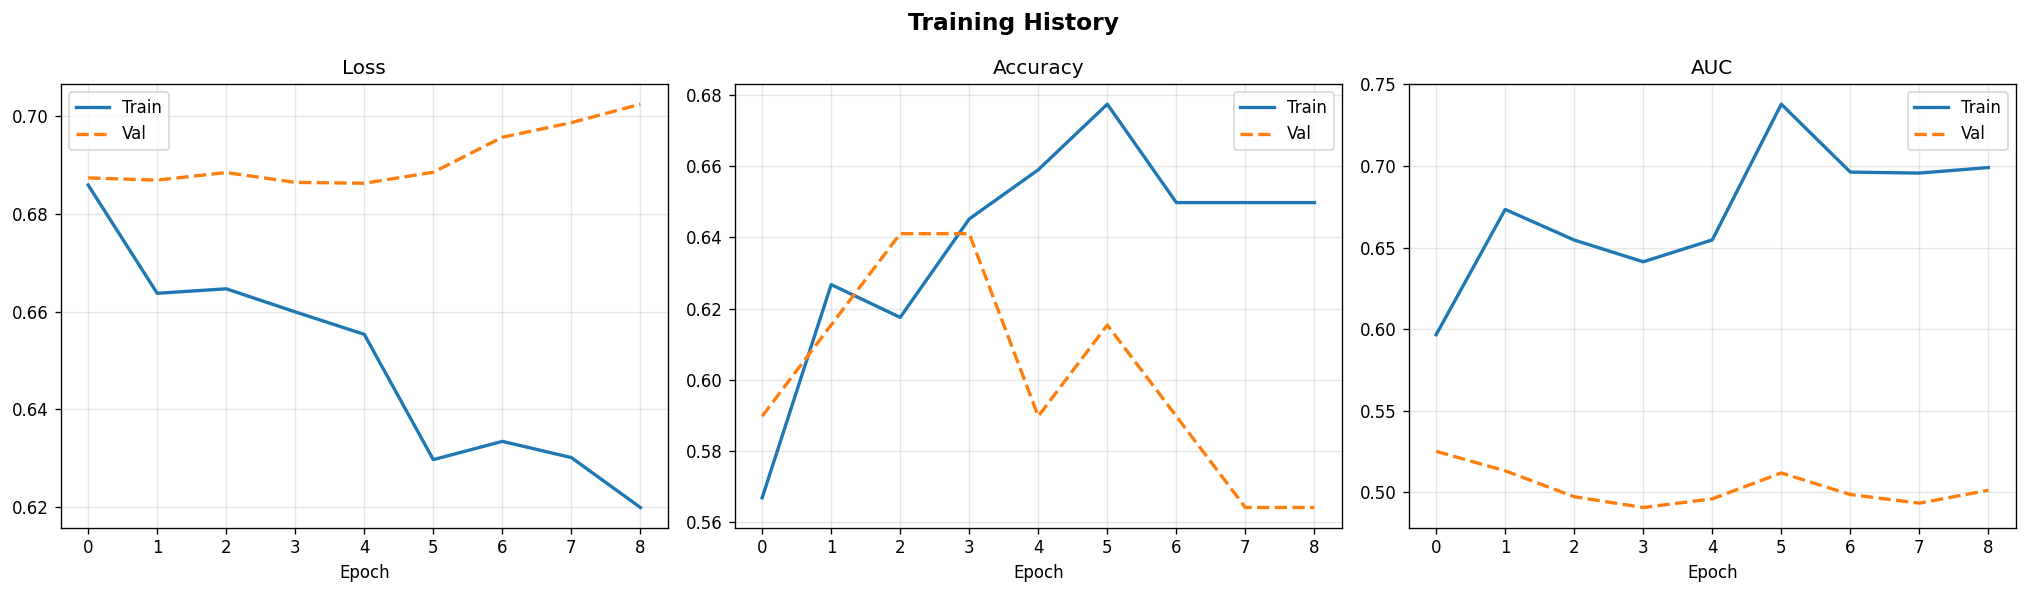

✅ Saved training_history.png


In [21]:
import matplotlib.pyplot as plt

# Create a figure with three subplots for displaying training history.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Iterate through metrics (loss, accuracy, auc) and plot their training and validation curves.
for ax, metric, title in zip(axes,
        ['loss', 'accuracy', 'auc'], ['Loss', 'Accuracy', 'AUC']):
    # Plot training metric.
    ax.plot(history.history[metric],           label='Train', linewidth=2)
    # Plot validation metric with a dashed line.
    ax.plot(history.history[f'val_{metric}'],  label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('training_history.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('✅ Saved training_history.png')

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step


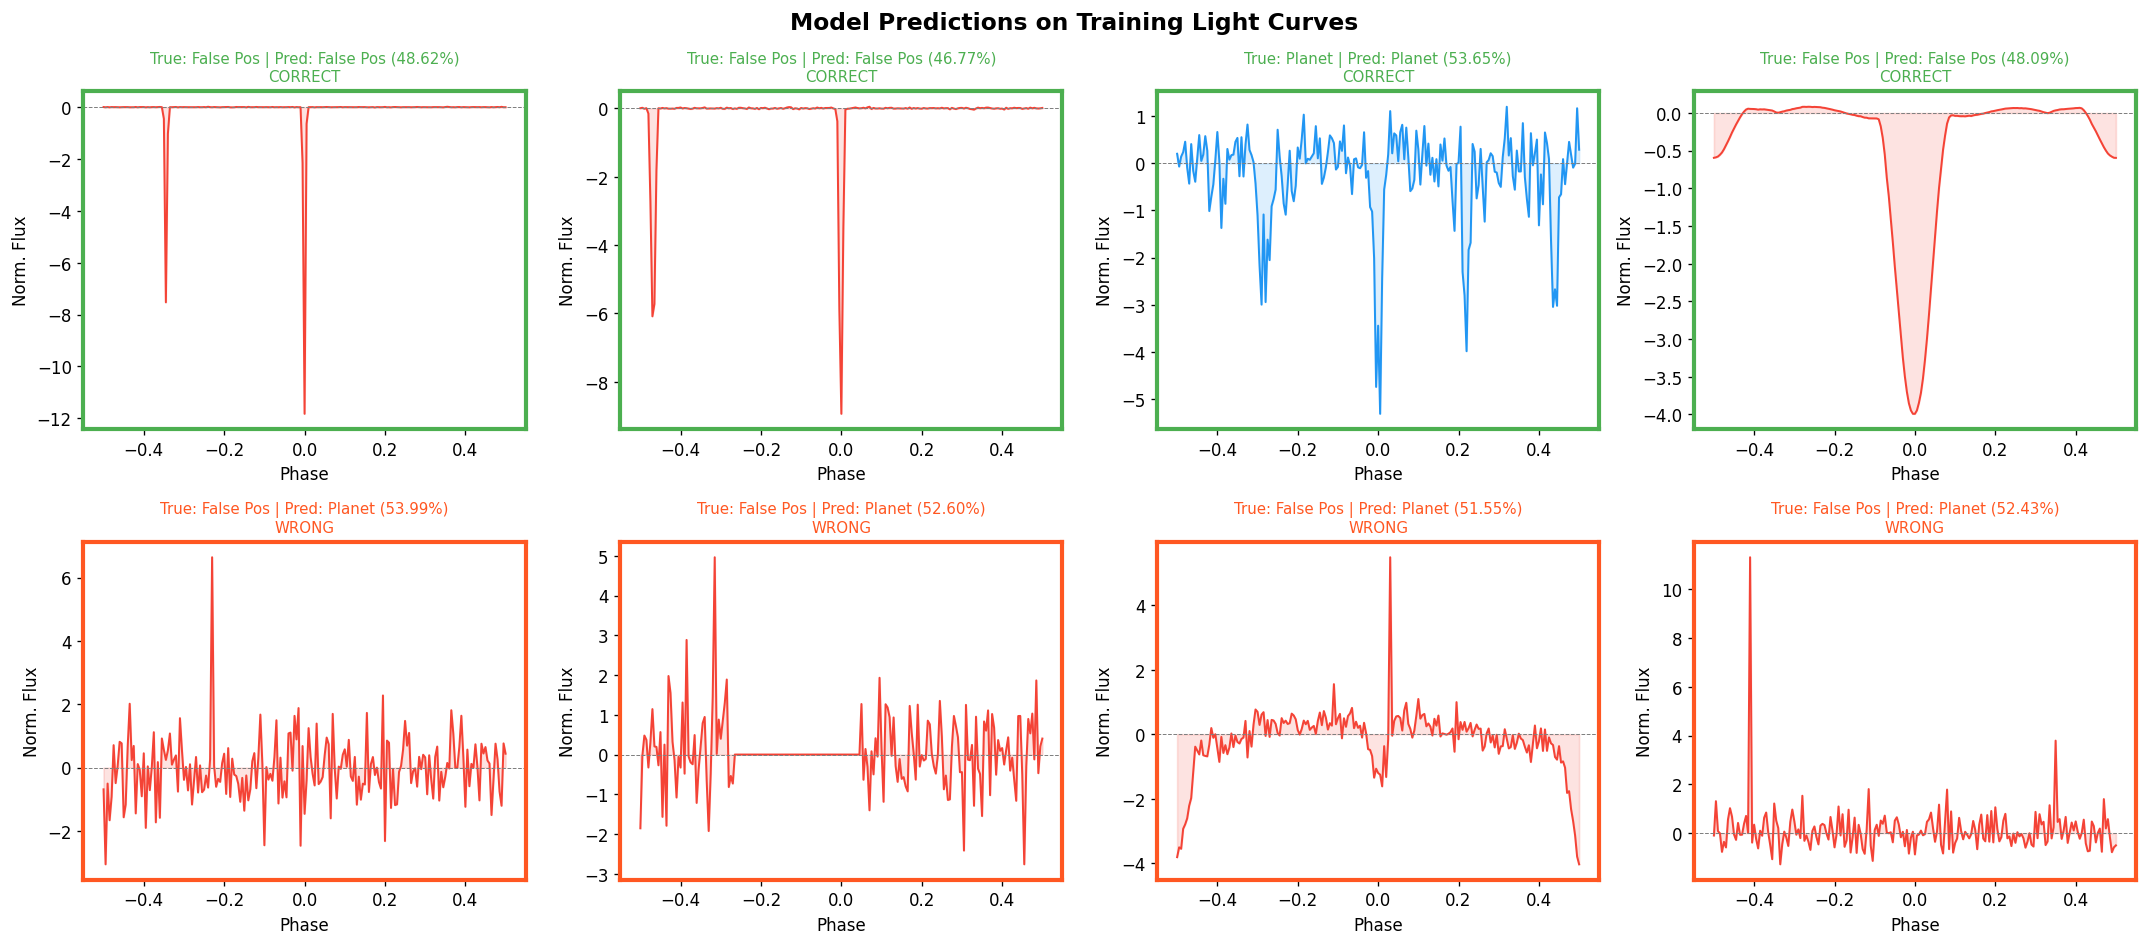

✅ Saved training_predictions_examples.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with a 2x4 grid of subplots for visualizing individual predictions on the training set.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Model Predictions on Training Light Curves', fontsize=14, fontweight='bold')

# Predict probabilities for the training set
y_prob_train = model.predict(X_train).flatten()
y_pred_train = (y_prob_train >= 0.5).astype(int)

# Get indices of correctly and incorrectly classified samples from the training set.
correct_idx_train = np.where(y_pred_train == y_train)[0][:4] # Get first 4 correctly classified samples
wrong_idx_train   = np.where(y_pred_train != y_train)[0][:4] # Get first 4 incorrectly classified samples
# Combine these indices for visualization.
indices_train = list(correct_idx_train) + list(wrong_idx_train)
# Define the x-axis for the phase-folded light curves.
x_axis = np.linspace(-0.5, 0.5, BINS)

# Iterate through the selected indices and plot each light curve with its prediction.
for i, idx in enumerate(indices_train[:8]): # Visualize up to 8 examples
    ax = axes[i // 4][i % 4]
    # Extract flux, predicted probability, and determine if the prediction was correct.
    flux    = X_train[idx].flatten()
    prob    = y_prob_train[idx]
    correct = y_pred_train[idx] == y_train[idx]
    # Determine true and predicted labels for display.
    true_lbl = 'Planet'    if y_train[idx] == 1 else 'False Pos'
    pred_lbl = 'Planet'    if y_pred_train[idx] == 1 else 'False Pos'
    # Set color based on true label.
    color   = '#2196F3'    if y_train[idx] == 1 else '#F44336'
    # Set border color based on prediction correctness.
    border  = '#4CAF50'    if correct         else '#FF5722'

    # Plot the light curve.
    ax.plot(x_axis, flux, color=color, linewidth=1.2)
    # Fill the area under the curve.
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    # Add a horizontal line at y=0.
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
    # Highlight the subplot border based on correctness.
    for spine in ax.spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(2.5)

    # Set the title with true label, predicted label, probability, and correctness status.
    status = 'CORRECT' if correct else 'WRONG'
    ax.set_title(f'True: {true_lbl} | Pred: {pred_lbl} ({prob:.2%})\n{status}', # Use .2% for percentage format
                 fontsize=9, color=border)
    ax.set_xlabel('Phase')
    ax.set_ylabel('Norm. Flux')

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('training_predictions_examples.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('✅ Saved training_predictions_examples.png')


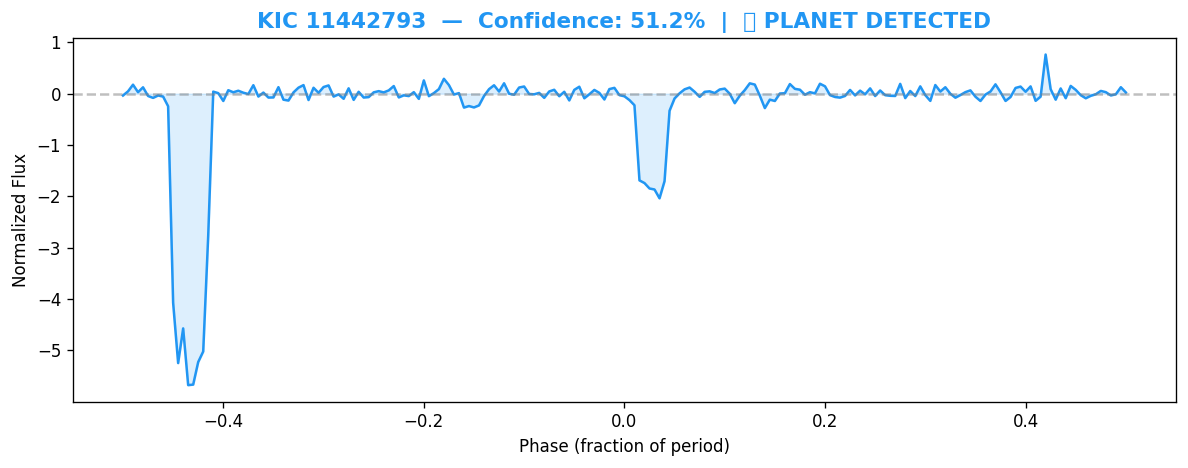

Score: 0.5125  ->  🪐 PLANET DETECTED


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ✏️ Edit these! User-defined parameters for the Kepler star to predict.
KEPLER_ID = 11442793   # Kepler ID of the star (e.g., Kepler-90)
PERIOD    = 14.44912   # Orbital period of the exoplanet candidate in days
T0        = 2.2        # Time of transit center (epoch) in BKJD

# Download and fold the light curve for the specified Kepler star.
flux = download_and_fold(KEPLER_ID, PERIOD, T0)

if flux is not None:
    # Reshape the flux data to be compatible with the model's input shape (1, BINS, 1).
    # Predict the probability of it being a planet using the trained model.
    prob    = model.predict(flux.reshape(1, BINS, 1), verbose=0)[0][0]
    # Determine the verdict based on the probability (threshold 0.5).
    verdict = '🪐 PLANET DETECTED' if prob >= 0.5 else '❌ FALSE POSITIVE'
    # Set the plot color based on the verdict.
    color   = '#2196F3'            if prob >= 0.5 else '#F44336'

    # Create a figure and an axial object for plotting.
    fig, ax = plt.subplots(figsize=(10, 4))
    # Define the x-axis for the phase-folded light curve.
    x_axis = np.linspace(-0.5, 0.5, BINS)
    # Plot the light curve.
    ax.plot(x_axis, flux, color=color, linewidth=1.5)
    # Fill the area under the curve.
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    # Add a horizontal reference line at y=0.
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    # Set the title with Kepler ID, confidence, and verdict.
    ax.set_title(f'KIC {KEPLER_ID}  —  Confidence: {prob:.1%}  |  {verdict}',
                 fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Phase (fraction of period)')
    ax.set_ylabel('Normalized Flux')
    # Adjust layout to prevent titles and labels from overlapping.
    plt.tight_layout()
    # Display the plot.
    plt.show()
    print(f'Score: {prob:.4f}  ->  {verdict}')
else:
    # If light curve download failed, print an error message.
    print('Could not download light curve for this KIC ID')

## 🧪 Step 8: Evaluate on Test Set

In [22]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
import seaborn as sns

# --- Check what we're working with ---
y_prob_raw = model.predict(X_test).flatten()
valid_mask = np.isfinite(y_prob_raw) & np.isfinite(y_test)
print(f"Total test samples : {len(y_test)}")
print(f"Valid samples      : {valid_mask.sum()}")
print(f"Dropped (NaN)      : {(~valid_mask).sum()}")

if valid_mask.sum() < 10:
    # Root cause: NaNs crept into X_test during preprocessing
    # Fix: re-clean X and y by replacing any remaining NaNs with 0
    print("\n⚠️  Too many NaNs — cleaning X_test in place...")
    X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    y_prob_raw   = model.predict(X_test_clean).flatten()
    valid_mask   = np.isfinite(y_prob_raw) & np.isfinite(y_test)
    print(f"Valid samples after clean: {valid_mask.sum()}")
    y_prob      = y_prob_raw[valid_mask]
    y_test_eval = y_test[valid_mask]
    X_eval      = X_test_clean[valid_mask]
else:
    y_prob      = y_prob_raw[valid_mask]
    y_test_eval = y_test[valid_mask]
    X_eval      = X_test[valid_mask]

y_pred = (y_prob >= 0.5).astype(int)

print(f"\nClass balance — Planets: {y_test_eval.sum():.0f}  |  False Pos: {(y_test_eval==0).sum():.0f}")

# --- Metrics ---
results = model.evaluate(X_eval, y_test_eval, verbose=0)
print('\n📊 TEST RESULTS')
print('='*40)
for name, val in zip(['Loss','Accuracy','AUC','Precision','Recall'], results):
    print(f'  {name:12s}: {val:.4f}')
print()
print(classification_report(y_test_eval, y_pred,
      target_names=['False Positive', 'Confirmed Planet'],
      labels=[0, 1]))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
Total test samples : 64
Valid samples      : 64
Dropped (NaN)      : 0

Class balance — Planets: 35  |  False Pos: 29

📊 TEST RESULTS
  Loss        : 0.6800
  Accuracy    : 0.6094
  AUC         : 0.6054
  Precision   : 0.5926
  Recall      : 0.9143

                  precision    recall  f1-score   support

  False Positive       0.70      0.24      0.36        29
Confirmed Planet       0.59      0.91      0.72        35

        accuracy                           0.61        64
       macro avg       0.65      0.58      0.54        64
    weighted avg       0.64      0.61      0.56        64



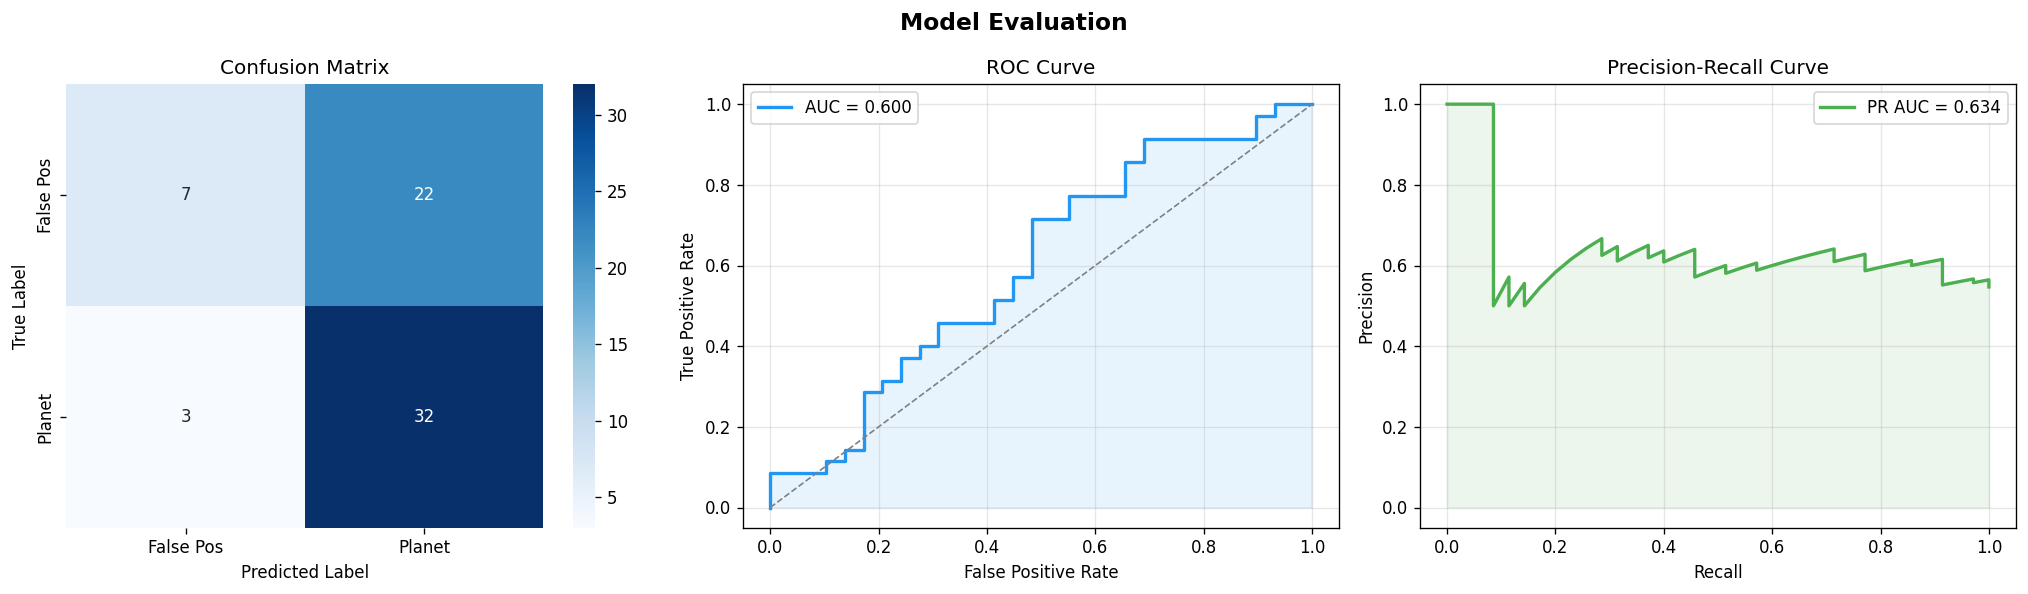

✅ Saved evaluation_plots.png


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
import seaborn as sns

# Create a figure with three subplots for model evaluation visualizations.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# --- Plot 1: Confusion Matrix ---
# Calculate the confusion matrix.
cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix using seaborn heatmap.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['False Pos','Planet'], yticklabels=['False Pos','Planet'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# --- Plot 2: ROC Curve ---
# Calculate False Positive Rate (fpr), True Positive Rate (tpr), and thresholds for the ROC curve.
fpr, tpr, _ = roc_curve(y_test, y_prob)
# Calculate the Area Under the ROC Curve (AUC).
roc_auc = auc(fpr, tpr)
# Plot the ROC curve.
axes[1].plot(fpr, tpr, '#2196F3', lw=2, label=f'AUC = {roc_auc:.3f}')
# Plot the random classifier line (diagonal).
axes[1].plot([0,1],[0,1],'gray', linestyle='--', lw=1)
# Fill the area under the ROC curve.
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Precision-Recall Curve ---
# Calculate precision, recall, and thresholds for the Precision-Recall curve.
prec, rec, _ = precision_recall_curve(y_test, y_prob)
# Calculate the Area Under the Precision-Recall Curve (PR AUC).
pr_auc = auc(rec, prec)
# Plot the Precision-Recall curve.
axes[2].plot(rec, prec, '#4CAF50', lw=2, label=f'PR AUC = {pr_auc:.3f}')
# Fill the area under the Precision-Recall curve.
axes[2].fill_between(rec, prec, alpha=0.1, color='#4CAF50')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('evaluation_plots.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('✅ Saved evaluation_plots.png')

## 🔮 Step 9: Visualize Individual Predictions

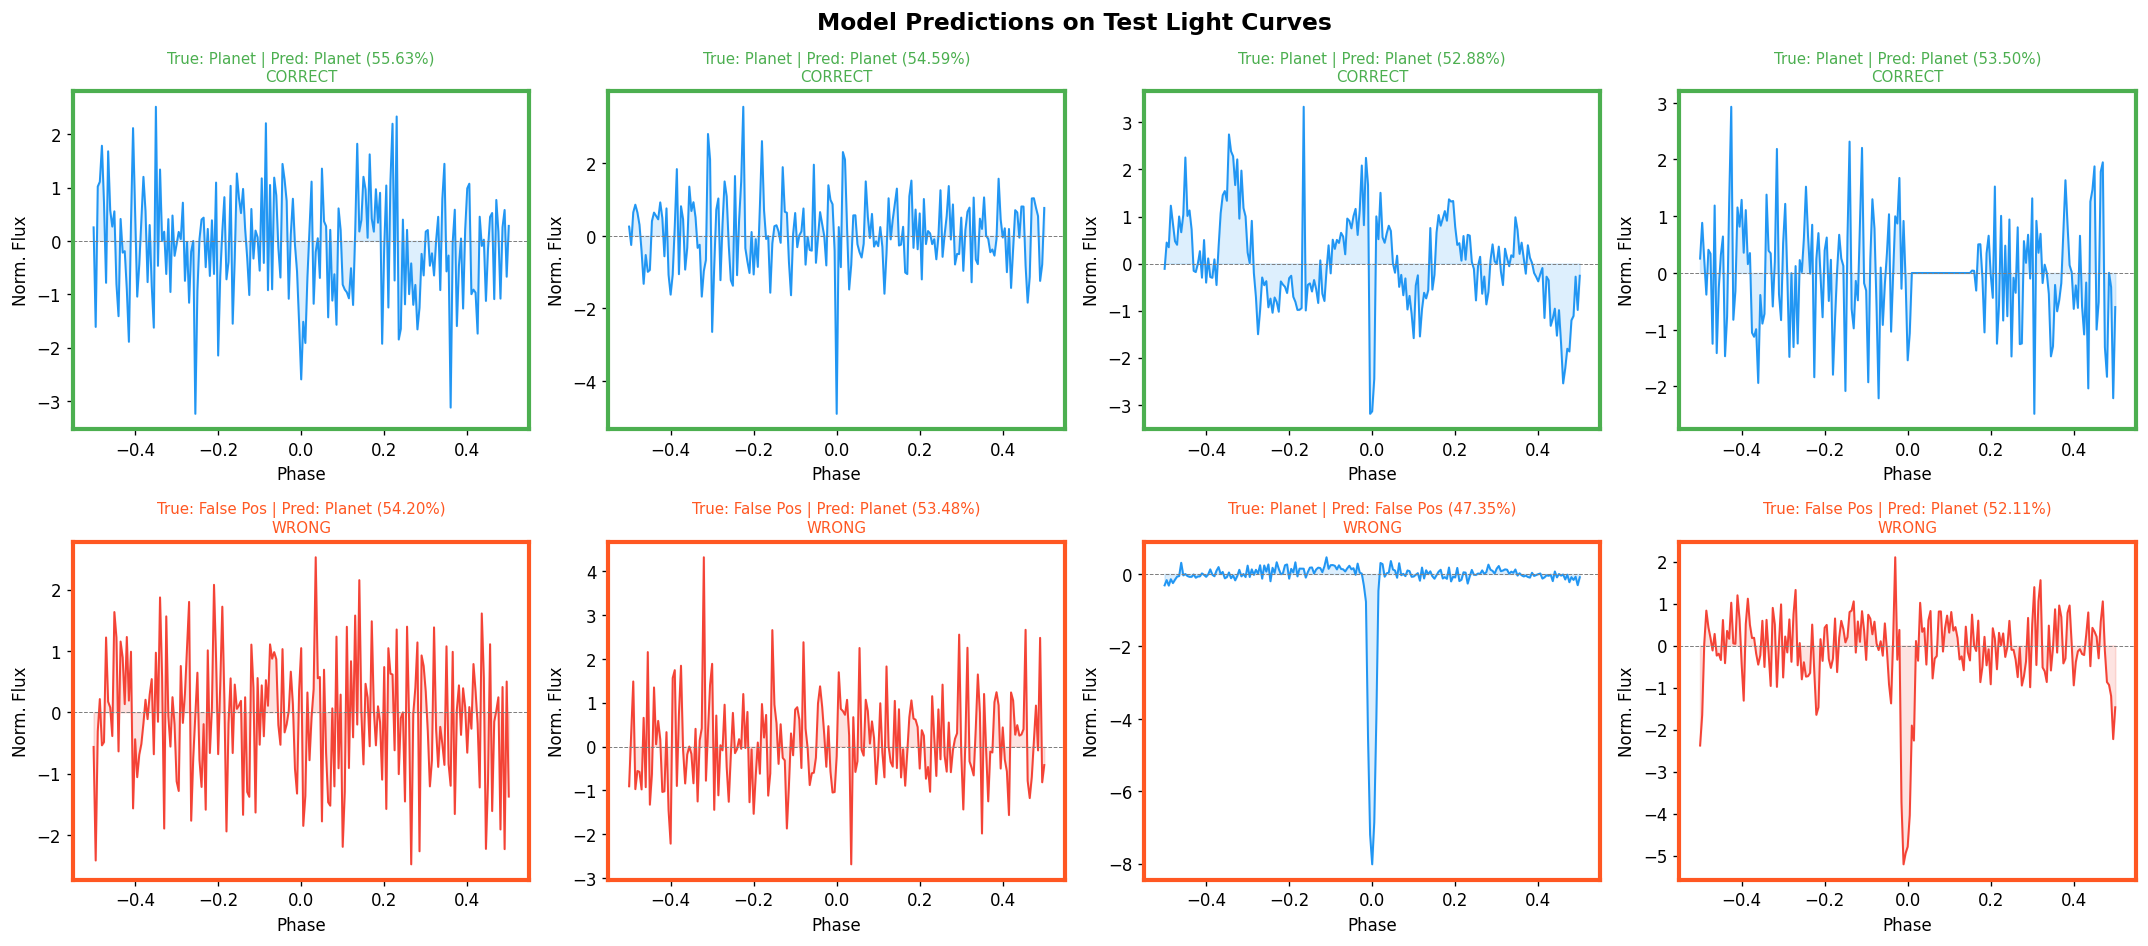

✅ Saved predictions_examples.png


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with a 2x4 grid of subplots for visualizing individual predictions.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Model Predictions on Test Light Curves', fontsize=14, fontweight='bold')

# Get indices of correctly and incorrectly classified samples from the test set.
correct_idx = np.where(y_pred == y_test)[0][:4] # Get first 4 correctly classified samples
wrong_idx   = np.where(y_pred != y_test)[0][:4] # Get first 4 incorrectly classified samples
# Combine these indices for visualization.
indices = list(correct_idx) + list(wrong_idx)
# Define the x-axis for the phase-folded light curves.
x_axis = np.linspace(-0.5, 0.5, BINS)

# Iterate through the selected indices and plot each light curve with its prediction.
for i, idx in enumerate(indices[:8]): # Visualize up to 8 examples
    ax = axes[i // 4][i % 4]
    # Extract flux, predicted probability, and determine if the prediction was correct.
    flux    = X_test[idx].flatten()
    prob    = y_prob[idx]
    correct = y_pred[idx] == y_test[idx]
    # Determine true and predicted labels for display.
    true_lbl = 'Planet'    if y_test[idx] == 1 else 'False Pos'
    pred_lbl = 'Planet'    if y_pred[idx] == 1 else 'False Pos'
    # Set color based on true label.
    color   = '#2196F3'    if y_test[idx] == 1 else '#F44336'
    # Set border color based on prediction correctness.
    border  = '#4CAF50'    if correct         else '#FF5722'

    # Plot the light curve.
    ax.plot(x_axis, flux, color=color, linewidth=1.2)
    # Fill the area under the curve.
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    # Add a horizontal line at y=0.
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
    # Highlight the subplot border based on correctness.
    for spine in ax.spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(2.5)

    # Set the title with true label, predicted label, probability, and correctness status.
    status = 'CORRECT' if correct else 'WRONG'
    ax.set_title(f'True: {true_lbl} | Pred: {pred_lbl} ({prob:.2%})\n{status}', # Use .2% for percentage format
                 fontsize=9, color=border)
    ax.set_xlabel('Phase')
    ax.set_ylabel('Norm. Flux')

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('predictions_examples.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('✅ Saved predictions_examples.png')

## 💾 Step 10: Save Model & Download All Outputs

In [25]:
# Save the trained Keras model to an HDF5 file.
model.save('exoplanet_cnn_model.h5')
print('✅ Model saved')

from google.colab import files
# Define a list of filenames to be downloaded.
for fname in ['exoplanet_cnn_model.h5',
              'lightcurve_examples.png',
              'training_history.png',
              'evaluation_plots.png',
              'predictions_examples.png']:
    # Use google.colab.files.download to trigger a download of each file.
    files.download(fname)

✅ Model saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🚀 (Optional) Step 11: Predict on Any Kepler Star

Change the values below to test any KOI.

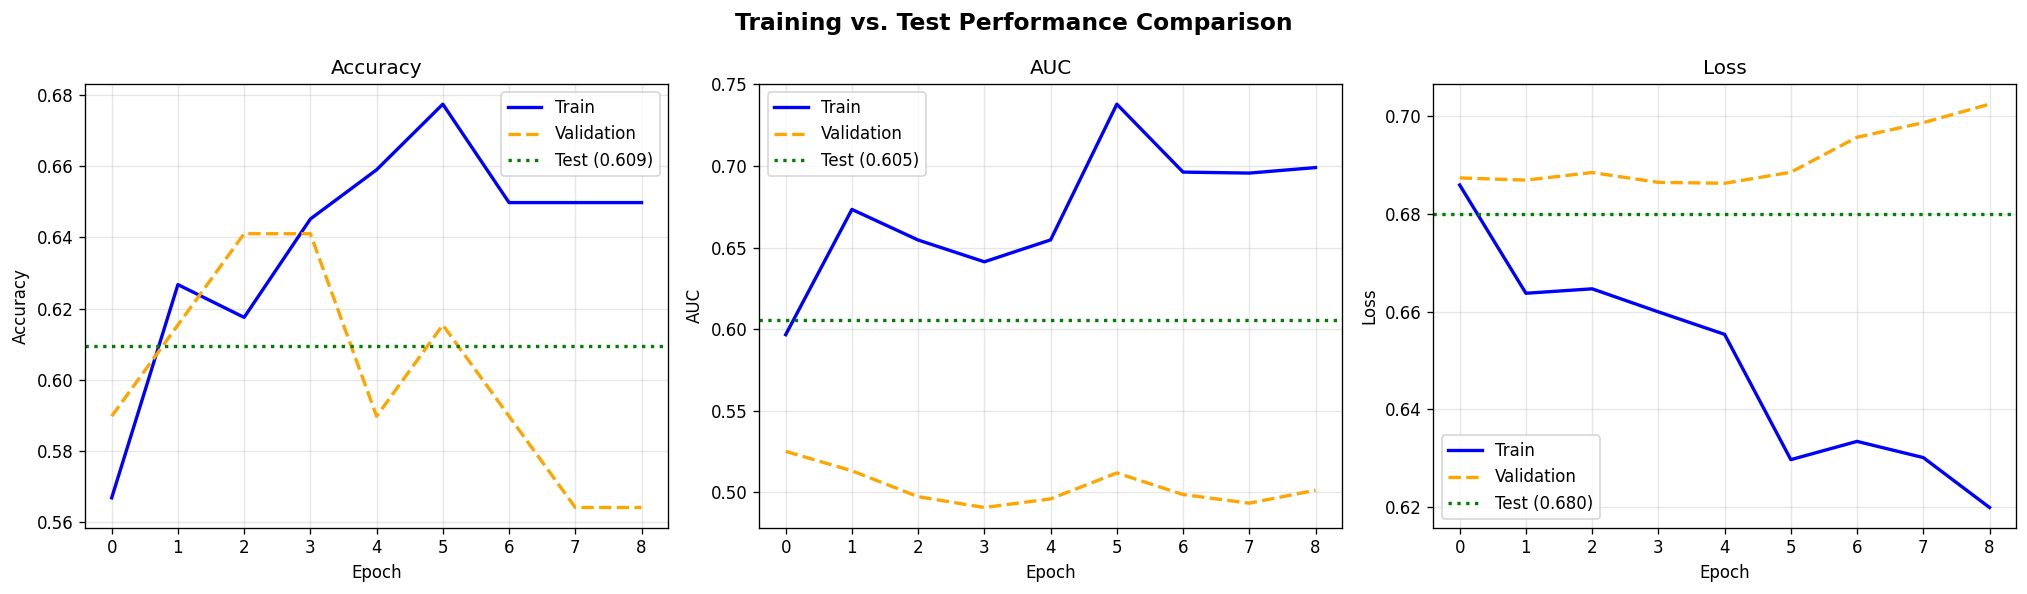

✅ Saved training_test_comparison.png


In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training vs. Test Performance Comparison', fontsize=14, fontweight='bold')

metrics_to_compare = ['accuracy', 'auc', 'loss']
metric_titles = ['Accuracy', 'AUC', 'Loss']

# Extract test metrics from the 'results' array
test_accuracy = results[1]
test_auc = results[2]
test_loss = results[0]

test_metrics = { 'accuracy': test_accuracy, 'auc': test_auc, 'loss': test_loss }

for i, (metric, title) in enumerate(zip(metrics_to_compare, metric_titles)):
    ax = axes[i]

    # Plot training and validation history
    ax.plot(history.history[metric], label='Train', linewidth=2, color='blue')
    ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2, linestyle='--', color='orange')

    # Plot test metric as a horizontal line or point
    ax.axhline(test_metrics[metric], color='green', linestyle=':', linewidth=2, label=f'Test ({test_metrics[metric]:.3f})')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_test_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Saved training_test_comparison.png')
